## Plotting

In [81]:
palette_muted = ["#4d4d4d", "#f0c571", "#59a89c", "#0b81a2", "#f45f74", "#9d2c00", "#c4a484", "#007b7b"]

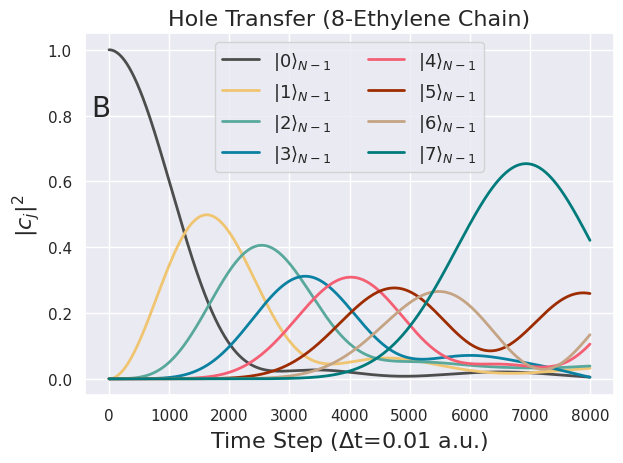

In [82]:
from scipy import linalg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from tools.bandh import make_h
sns.set()

def c_to_charges(c,las_charges):
    p = np.real(c * c.conj())
    assert(np.allclose(p.sum(),1,atol=1e-4))
    charges = las_charges #cut out gs
    charges = (charges * p[:,None]).sum(axis=0)
    return charges

# H = make_h(civecs_lassi,energies_lassi,plot=False)
cs = np.load("cs-hole.npy")
cs2 = cs * cs.conj()

df = pd.DataFrame(cs2[:,1:]) #cut out ground state
for col in df.columns:
    x = df.index
    y = np.real(df[col])
    plt.plot(x,y,label = f"|{col}⟩" + "$_{N-1}$", color=palette_muted[col],linewidth=2)
fs = 16
plt.legend(loc="upper center",ncols=1,fontsize=9,prop={'size': 13},ncol=2)
plt.xlabel(r"Time Step ($\Delta$t=0.01 a.u.)",fontsize=fs)
plt.ylabel("$|c_j|^2$",fontsize=fs)
plt.title("Hole Transfer (8-Ethylene Chain)",fontsize=fs)
plt.annotate("B",(-300,0.8),fontsize=20)
plt.tight_layout()
# plt.savefig("./ethylenect_hole_coeff.pdf",dpi=500)


<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1081/3505033686.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("Time Step ($\Delta$t=0.01 a.u.)",fontsize=fs)


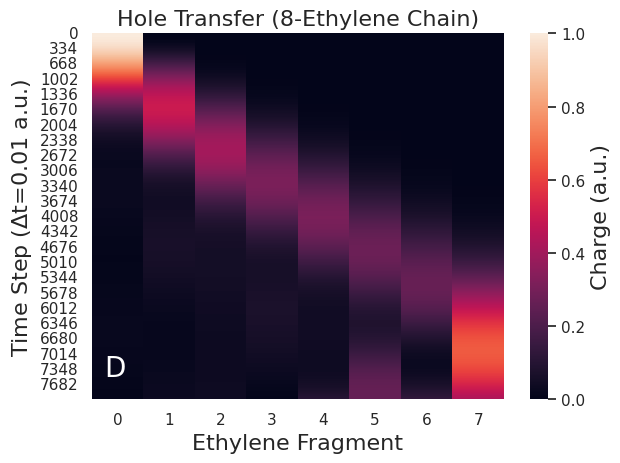

In [4]:
charges_all = []
las_charges = np.load("las_charges-hole.npy")
for c in cs:
    charges = c_to_charges(c,las_charges)
    charges_all += [charges]
charges = np.vstack(charges_all)
fs = 16
ax = sns.heatmap(charges,cmap="rocket",cbar_kws={'label': 'Charge (a.u.)'})
plt.ylabel("Time Step ($\Delta$t=0.01 a.u.)",fontsize=fs)
plt.xlabel("Ethylene Fragment",fontsize=fs)
plt.title("Hole Transfer (8-Ethylene Chain)",fontsize=fs)
# plt.colorbar().set_label(size=13)
plt.annotate("D",(0.25,7500),fontsize=20,c="white")
ax.figure.axes[-1].yaxis.label.set_size(16)
plt.tight_layout()
# plt.savefig("figures/ethylenect_hole_charge.png",dpi=500)

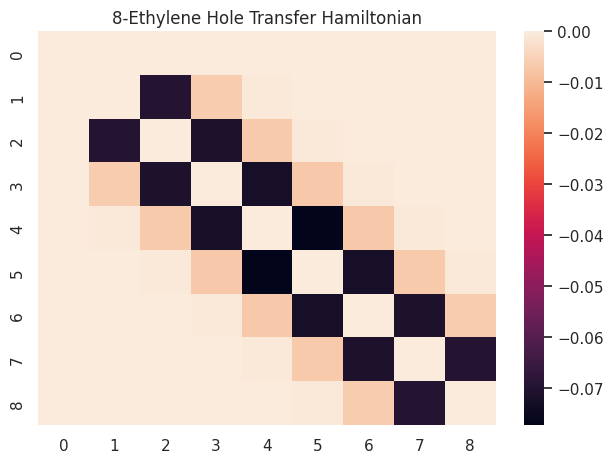

In [5]:
# H = make_h(civecs_lassi,energies_lassi,plot=False)
H = np.load("ham-hole.npy")
H = H - np.diag(np.diag(H))
sns.heatmap(H)
plt.title("8-Ethylene Hole Transfer Hamiltonian")
plt.tight_layout()
# plt.savefig("figures/ct_hamiltonian_hole_nodiag.png",dpi=500)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1081/1615658835.py:6: SyntaxWarning: invalid escape sequence '\l'
  sns.heatmap(H,cbar_kws={'label': "$\log_{10}(|H_{ij}|)$"})


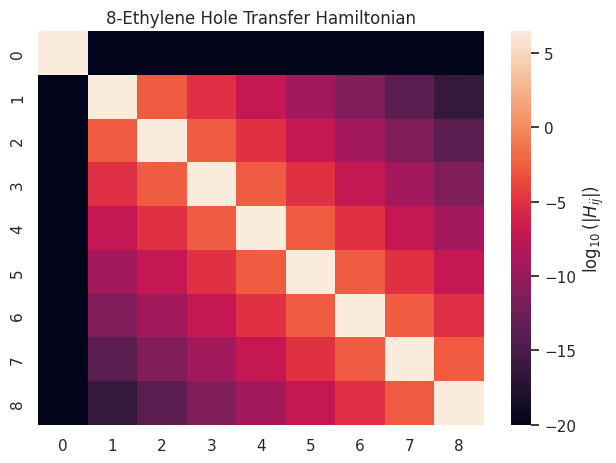

In [6]:
# H = make_h(civecs_lassi,energies_lassi,plot=False)
H = np.load("ham-hole.npy")
for i in range(H.shape[0]):
    H[i][np.where(H[i] != 0)] = np.log(np.abs(H[i][np.where(H[i] != 0)]))
    H[i][np.where(H[i] == 0)] = -20
sns.heatmap(H,cbar_kws={'label': "$\log_{10}(|H_{ij}|)$"})
plt.title("8-Ethylene Hole Transfer Hamiltonian")
plt.tight_layout()
# plt.savefig("figures/ct_hamiltonian_hole_log.png",dpi=500)